# Tarea 5.
# Clase de Introduction to Machine Learning
#### Alumno Carlos Alfonzo
## Implementación de Perceptrón Multicapa (Una Capa Oculta) con JAX y MNIST

Aquí se implementa el algoritmo utilizando dos formas diferentes sobre el dataset MNIST:
- La primera usará la implementación matricial clásica (cálculo de gradientes manual).
- La segunda usará la función forward con diferenciación automática (`jax.grad`).
- Ambas usarán la función de costo de Entropía Cruzada (Cross-Entropy) para la clasificación de clases, usando la función Softmax.

In [1]:
# Importe de librerias
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml # para cargar MNIST
from sklearn.model_selection import train_test_split #para  dividir el dataset de manera rapida
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, ConfusionMatrixDisplay

# Cargamos el dataset MNIST
print("Cargando dataset MNIST")
mnist = fetch_openml('mnist_784', #acá usamos la función fetch_openml para cargar el dataset MNIST, que consiste de imágenes de dígitos escritos a mano. el argumento 'mnist_784': se refiere a la versión del dataset MNIST que contiene 70,000 imágenes, cada una con 784 características (28x28 píxeles).
                     version=1, # la version 1 del dataset MNIST porque es la  más comúnmente utilizada.
                     cache=True, # con cache=True el dataset se almacenará en caché localmente después de la primera descarga, para evitar descargar el dataset cada vez que se ejecuta el código
                     parser='auto')#- para detectar automáticamente el formato del dataset. En este caso, el dataset MNIST se encuentra en formato CSV.

X = mnist.data.values.astype(np.float32) / 255.0 # Normalizamos los pixeles entre 0 y 1 al
y = mnist.target.values.astype(np.int32) # y los targets son    enteros del 0 al 9 representando cada dígito.

# Usamos un subconjunto de 10,000 imágenes para un entrenamiento más rápido
X, _, y, _ = train_test_split(X, y, train_size=10000, stratify=y, random_state=42) #usamos el clasico 42 para la semilla

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)# Dividimos en entrenamiento y prueba (80 y 20)

print(f"Dimensiones para el conjunto de entrenamiento: X={X_train.shape}, y={y_train.shape}")
print(f"Dimensiones para la prueba: X={X_test.shape}, y={y_test.shape}")

# Convertimos a arrays de JAX, le agregamos el _j
X_train_j = jnp.array(X_train)
y_train_j = jnp.array(y_train)
X_test_j = jnp.array(X_test)

# Convertimos las etiquetas a formato One-Hot (10 clases), que significa que cada etiqueta se representa como un vector de 10 elementos, donde el índice correspondiente a la clase es 1 y el resto son 0. Esto es necesario para la función de pérdida de entropía cruzada que usaremos.
def one_hot(x, k, dtype=jnp.float32):
    return jnp.array(x[:, None] == jnp.arange(k), dtype) #usamos None para agregar una dimensión extra a x, lo que permite comparar cada elemento de x con cada índice de jnp.arange(k) y crear la matriz one-hot resultante.

Y_train_j = one_hot(y_train_j, 10) # Convertimos las etiquetas de entrenamiento a formato one-hot, donde 10 es el número de clases

Cargando dataset MNIST


Dimensiones para el conjunto de entrenamiento: X=(8000, 784), y=(8000,)
Dimensiones para la prueba: X=(2000, 784), y=(2000,)


### Inicialización de Parámetros y Funciones Auxiliares

Definimos una red con una capa oculta de 64 neuronas. La entrada, como dijimos es de 784 (imágenes de 28x28) y la salida es 10 (clases 0-9).
Usamos **ReLU (REctified Linear Unit)** en la capa oculta y **Softmax** en la salida.

Vamos a usar la **inicialización tipo He** para los pesos, que es adecuada para redes con activaciones ReLU. Esto ayuda a mantener la varianza de las activaciones constante a través de las capas, lo que mejora la convergencia durante el entrenamiento.

In [2]:
np.random.seed(42) # la clasica semilla en 42
# Inicialización tipo He para ReLU para evitar
# Capa oculta (entrada 784 y en la capa de 64)
n_entrada = 784
n_oculta = 64
n_salida = 10
W1 = jnp.array(np.random.randn(n_entrada, n_oculta) * np.sqrt(2.0 / n_entrada))# lo multiplicamos por raiz(2.0 / 784) para mantener la varianza de las activaciones constante a través de las capas, lo que ayuda a evitar problemas de desvanecimiento o explosión del gradiente durante el entrenamiento.
b1 = jnp.zeros(n_oculta) #b1  es el vector de sesgos para la capa oculta, inicializado en ceros

# Capa de salida (de la oculta de 64 a una salida de 10 clases posibles)
W2 = jnp.array(np.random.randn(n_oculta, n_salida) * np.sqrt(2.0 / n_oculta))#para los pesos de la capa de salida, también usamos la inicialización tipo He, multiplicando por sqrt(2.0 / n_oculta) para mantener la varianza de las activaciones constante.
b2 = jnp.zeros(n_salida) # el bias  de la capa de salida, también inicializado en ceros.

def relu(x):
    return jnp.maximum(0, x) # si es negativo, se convierte en 0, añade no linearidad

def softmax(x):
    # Restamos el máx por estabilidad numérica,  para evitar que los exponentes se vuelvan demasiado grandes y causen overflow. Al restar el máximo, garantizamos que el valor más grande en x sea 0, lo que mantiene los exponentes en un rango manejable.
    exp_x = jnp.exp(x - jnp.max(x, axis=1, keepdims=True)) #    calculamos la función softmax, que convierte los logits (valores de salida de la ultima capa) en probabilidades. Primero, restamos el máximo de cada fila para mejorar la estabilidad numérica, luego aplicamos la función exponencial y finalmente normalizamos dividiendo por la suma de los exponentes a lo largo de cada fila.
    return exp_x / jnp.sum(exp_x, axis=1, keepdims=True)#keepdims en True significa que la dimensión de la suma se mantiene, lo que permite que la división se realice correctamente para cada fila.

def cross_entropy(P, Y): #nuestra función de pérdida de entropía cruzada, que mide la diferencia entre las probabilidades predichas (P) y las etiquetas reales (Y). toma el logaritmo de las probabilidades predichas, lo multiplica por las etiquetas reales, y las promedia sobre todas las muestras. El 1e-9 se agrega para evitar tomar el logaritmo de 0
    return -jnp.mean(jnp.sum(Y * jnp.log(P + 1e-9), axis=1))#el negativo es porque se quiere maximizar la probabilidad de las etiquetas reales, lo que equivale a minimizar la entropía cruzada.

### 1. Implementación Matricial Clásica

Calculamos explícitamente los gradientes usando derivadas matriciales. Compilamos la función de actualización con @jax.jit (Just In Time) para acelerar las operaciones.

In [3]:
@jax.jit
def manual_update(W1, b1, W2, b2, X, Y, lr):
    N = X.shape[0]
    # Aca viene el forward pass
    Z1 = jnp.dot(X, W1) + b1# primero calculamos los logits de la capa oculta (Z1) multiplicando la entrada X por los pesos W1 y sumando el sesgo b1.
    H = relu(Z1) #Luego, aplicamos la función de activación ReLU a Z1 para obtener las activaciones H de la capa oculta.
    Z2 = jnp.dot(H, W2) + b2 # Después, calculamos los logits de la capa de salida (Z2) multiplicando las activaciones H por los pesos W2 y sumando el sesgo b2.
    P = softmax(Z2)#Finalmente, aplicamos la función softmax a Z2 para obtener las probabilidades P de cada clase
    loss = cross_entropy(P, Y) # Calculamos la perdida aplicando la función a  las probabilidades predichas P y las etiquetas reales Y
    # Backward Pass (Gradientes manuales)
    # Gradiente en la capa de salida (Softmax + CrossEntropy)
    dZ2 = P - Y#    El gradiente de la capa de salida (dZ2) se calcula restando las etiquetas reales Y de las probabilidades predichas P
    dW2 = jnp.dot(H.T, dZ2) / N #   calculamos  el gradiente de los pesos de la capa de salida (dW2) multiplicando la transpuesta de las activaciones H por dZ2 y dividiendo por el número de muestras N para obtener el promedio del gradiente.
    db2 = jnp.sum(dZ2, axis=0) / N# acá sumamos dZ2 a lo largo de las filas (axis=0) para obtener el gradiente del sesgo de la capa de salida (db2) y luego lo dividimos por N para obtener el promedio.
    
    # Gradiente en la capa oculta
    dH = jnp.dot(dZ2, W2.T) #   calculamos el gradiente de las activaciones de la capa oculta (dH) multiplicando dZ2 por la transpuesta de los pesos W2. Esto propaga el error hacia atrás desde la capa de salida a la capa oculta
    dZ1 = dH * (Z1 > 0) # Acá aplicamos la derivada de la función ReLU para obtener el gradiente de los logits de la capa oculta (dZ1)
    dW1 = jnp.dot(X.T, dZ1) / N#de nuevo calculamos el gradiente de los pesos
    db1 = jnp.sum(dZ1, axis=0) / N# y   el gradiente del sesgo de la capa oculta
    
    # fase de actualización del gradiente descendiente
    W1 -= lr * dW1 #    actualizamos los pesos W1 restando el producto de la tasa de aprendizaje (lr) y el gradiente dW1. Esto mueve los pesos en la dirección que minimiza la función de pérdida.
    #Así para los demás parametros b1, W2, b2
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    
    return W1, b1, W2, b2, loss # regresamos}  los parámetros actualizados y el valor de la pérdida para monitorear el entrenamiento.

def train_manual(X, Y, W1, b1, W2, b2, lr=0.5, epochs=300):
    historial_loss = []
    for epoch in range(epochs):
        W1, b1, W2, b2, loss = manual_update(W1, b1, W2, b2, X, Y, lr)
        historial_loss.append(loss)
        if epoch % 50 == 0:
            print(f"Manual - Epoch {epoch}, Loss: {loss:.4f}") #4 decimales
    return W1, b1, W2, b2, historial_loss

print("Entrenando con   Implementación manual")
W1_m, b1_m, W2_m, b2_m, loss_manual = train_manual(X_train_j, Y_train_j, W1.copy(), jnp.copy(b1), W2.copy(), jnp.copy(b2), lr=0.5, epochs=300) #usamos .copy() para asegurarnos de que cada implementación comience con los mismos pesos iniciales, una tasa de aprendizaje de 0.5 y entrenamos durante 300 corridas.

Entrenando con   Implementación manual
Manual - Epoch 0, Loss: 2.4224
Manual - Epoch 50, Loss: 0.3510
Manual - Epoch 100, Loss: 0.2434
Manual - Epoch 150, Loss: 0.1950
Manual - Epoch 200, Loss: 0.1625
Manual - Epoch 250, Loss: 0.1383


### 2. Implementación con Diferenciación Automática (JAX Autodiff)

Usamos `jax.value_and_grad` para que JAX haga la diferenciación de forma automática sobre el *forward pass*.

In [4]:
# Función forward que devuelve logits
def forward(params, X): #acá definimos la función forward que toma los parámetros de la red (params) y la entrada X, y devuelve los logits de la capa de salida. Desempaquetamos los parámetros en W1_ad, b1_ad, W2_ad, b2_ad, luego calculamos los logits de la capa oculta (Z1), aplicamos la función de activación ReLU para obtener las activaciones H, y finalmente calculamos los logits de la capa de salida (Z2) multiplicando H por W2_ad y sumando b2_ad.
    W1_ad, b1_ad, W2_ad, b2_ad = params
    Z1 = jnp.dot(X, W1_ad) + b1_ad
    H = relu(Z1)
    Z2 = jnp.dot(H, W2_ad) + b2_ad
    return Z2
# Función de costo
def loss_fn(params, X, Y):
    Z2 = forward(params, X)# hacemos el forward pass para obtener los logits de la capa de salida (Z2)
    P = softmax(Z2)# aplicamos la función softmax a Z2 para obtener las probabilidades P
    return cross_entropy(P, Y)# Calculamos la pérdida de entropía cruzada entre las probabilidades predichas P y las etiquetas reales Y.

# jit compila la función para que corra super rápido
@jax.jit
def update(params, X, Y, lr=0.5):
    # value_and_grad calcula el valor del loss y los gradientes simultáneamente
    loss, grads = jax.value_and_grad(loss_fn)(params, X, Y)
    # Actualizamos los parámetros restando el producto de la tasa de aprendizaje (lr) y los gradientes calculados por JAX. Esto mueve los parámetros en la dirección que minimiza lafunción de pérdida
    new_params = [p - lr * g for p, g in zip(params, grads)]
    return new_params, loss

def train_autodiff(X, Y, W1, b1, W2, b2, lr=0.5, epochs=300):
    params = [W1, b1, W2, b2]#  inicializamos los parámetros en una lista para pasarlos a la función de actualización.
    historial_loss = []#para guardar el valor de la pérdida en cada época y asi graficar la curva de convergencia luego
    for epoch in range(epochs):
        params, loss = update(params, X, Y, lr) #actualizamos los parámetros usando la función de actualización que utiliza diferenciación automática, y obtenemos el valor de la pérdida para monitorear el entrenamiento.
        historial_loss.append(loss)# añadimos la perdida
        if epoch % 50 == 0: #imprimos en consola cada 50 corridas
            print(f"Autodiff - Epoch {epoch}, Loss: {loss:.4f}")
    return params, historial_loss

print("entrenando Implementación Autodiff")
params_ad, loss_autodiff = train_autodiff(X_train_j,
                                          Y_train_j,
                                          W1.copy(), #copiamos  los pesos iniciales
                                          jnp.copy(b1), #también los sesgos iniciales
                                          W2.copy(), #  y para la capa de salida
                                          jnp.copy(b2), #y sus sesgos
                                          lr=0.5, #hiperparámetro de tasa de aprendizaje
                                          epochs=300)

entrenando Implementación Autodiff
Autodiff - Epoch 0, Loss: 2.4224
Autodiff - Epoch 50, Loss: 0.3511
Autodiff - Epoch 100, Loss: 0.2434
Autodiff - Epoch 150, Loss: 0.1950
Autodiff - Epoch 200, Loss: 0.1625
Autodiff - Epoch 250, Loss: 0.1383


### (c) Tasa de Convergencia (Loss Curve)

Graficamos la función de pérdida durante el entrenamiento para evaluar la tasa de convergencia de ambos algoritmos.

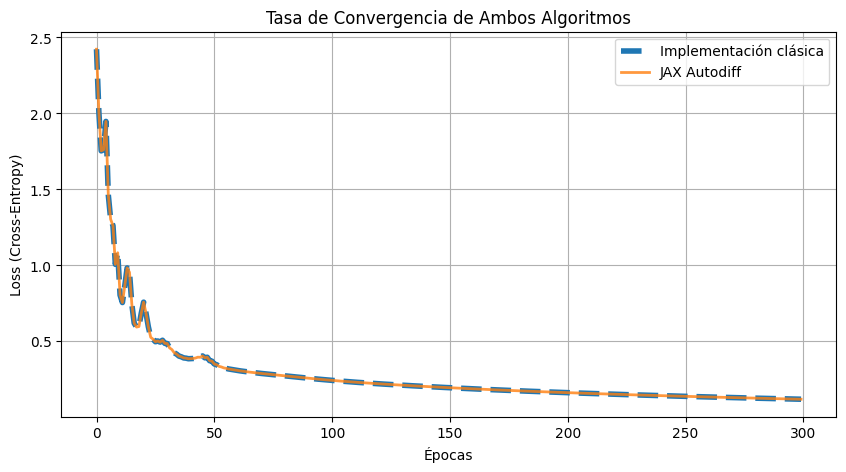

In [5]:
plt.figure(figsize=(10, 5))#tamaño de 10 de ancho y 5 de alto
plt.plot(loss_manual, label="Implementación clásica", linestyle="--", linewidth=4)
plt.plot(loss_autodiff, label="JAX Autodiff", alpha=0.8, linewidth=2)
plt.title("Tasa de Convergencia de Ambos Algoritmos")
plt.xlabel("Épocas")
plt.ylabel("Loss (Cross-Entropy)")
plt.legend()
plt.grid(True)
plt.show()

Como se puede observar en la gráfica, ambas curvas de pérdida (loss) se superponen casi perfectamente, lo que indica que ambos algoritmos están calculando exactamente el mismo gradiente y, por lo tanto, tienen la misma tasa de convergencia. Esto es una evidencia clara de que la implementación manual y la diferenciación automática de JAX están produciendo resultados equivalentes en términos de optimización del modelo.
Asimismo, al inicio el descenso de la función de pérdida es muy notorio, con una caída que se ve en una pendiente mayor que se va suavizando al llegar a la época 50 aproximadamente.

### (a) La Matriz de Confusión Clásica y (b) Precisión / Sensibilidad (Recall)

Evaluamos el modelo final en el conjunto de prueba (2000 imágenes).

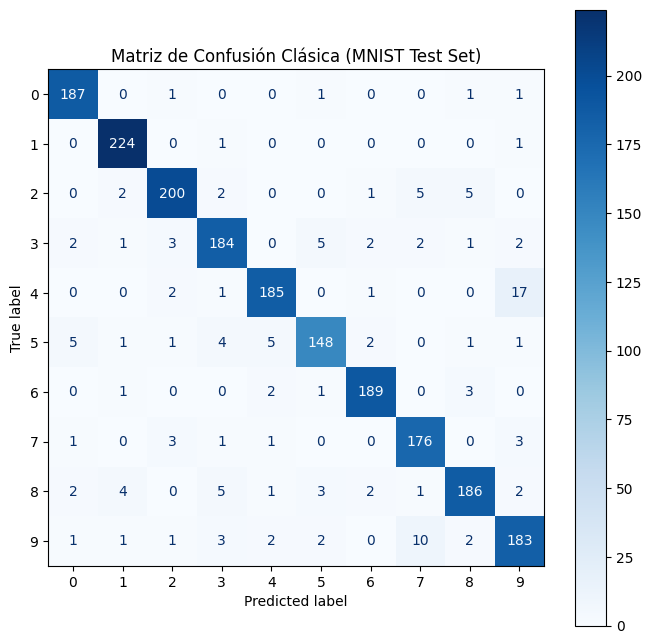

Reporte de Precisión y Recall por Clase ígitos 0-9
Clase     | Precisión      | Recall         , F1-Score       
Dígito 0  | 0.9444         | 0.9791         | 0.9614         
Dígito 1  | 0.9573         | 0.9912         | 0.9739         
Dígito 2  | 0.9479         | 0.9302         | 0.9390         
Dígito 3  | 0.9154         | 0.9109         | 0.9132         
Dígito 4  | 0.9439         | 0.8981         | 0.9204         
Dígito 5  | 0.9250         | 0.8810         | 0.9024         
Dígito 6  | 0.9594         | 0.9643         | 0.9618         
Dígito 7  | 0.9072         | 0.9514         | 0.9288         
Dígito 8  | 0.9347         | 0.9029         | 0.9185         
Dígito 9  | 0.8714         | 0.8927         | 0.8819         
Promedio  , 0.9307         , 0.9302         , 0.9301         


In [6]:
# Realizamos predicciones sobre el conjunto de prueba
logits = forward(params_ad, X_test_j) #obtenemos los logits de la capa de salida para el conjunto de prueba usando la función forward con los parámetros entrenados con autodiff.
y_pred = np.array(jnp.argmax(logits, axis=1)) # obtenemos las predicciones finales tomando el índice del valor máximo en los logits a lo largo de las filas (axis=1)

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred) # generamos la matriz de confusión comparando etiquetas reales (y_test) con las predicciones (y_pred). La matriz muestra el núm de aciertos y errores para cada clase, lo que permite evaluar el rendimiento del modelo en clasificación
disp = ConfusionMatrixDisplay(confusion_matrix=cm) #aca lo visualizamos
fig, ax = plt.subplots(figsize=(8, 8)) #tamaño de 8x8 para que se vea bien
disp.plot(cmap='Blues', ax=ax, values_format='d') #'d' para mostrar los valores enteros en cada celda de la matriz, cmap='Blues' para usar una paleta de colores azules
plt.title("Matriz de Confusión Clásica (MNIST Test Set)")
plt.show()

# Función Precisión-Recall, el reporte por clase
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred) #usamos la funcion de la libreria  sklearn para calcular la precisión, recall, f1-score y soporte, el soporte no lo usamos, por eso el _

print("Reporte de Precisión y Recall por Clase ígitos 0-9")
print(f"{'Clase':<10}| {'Precisión':<15}| {'Recall':<15}, {'F1-Score':<15}")
for i in range(10):
    print(f"Dígito {i:<3}| {precision[i]:<15.4f}| {recall[i]:<15.4f}| {f1[i]:<15.4f}")

print(f"Promedio  , {np.mean(precision):<15.4f}, {np.mean(recall):<15.4f}, {np.mean(f1):<15.4f}")

### (d) ¿Cuáles son las diferencias entre ambos algoritmos?

Aunque calculan lo mismo (como se demuestra en la gráfica de convergencia, donde ambas líneas se sobreponen, tienen diferencias en su concepción e implementación:

1. **Complejidad de Programación y Escalabilidad:**
   - *Implementación Matricial:* Requiere derivar a mano cada ecuación usando la regla de la cadena para cada capa. Es propenso a errores  de signo o transposición de matrices. Si cambiamos la función de activación (ej. de ReLU a Sigmoid) o agregamos una capa de más, tenemos que volver a calcular y reprogramar el *backward pass* desde cero.
   - *Autodiff (JAX):* JAX construye un grafo computacional de la función forward y aplica derivación algorítmica. Podemos agregar varias capas o cambiar la arquitectura libremente y JAX seguirá calculando el gradiente exacto en una sola línea de código (`jax.grad`).

2. **Mantenimiento y Legibilidad del Código:**
   - El código *Autodiff* es más modular y enfocado  en la arquitectura de la red (forward).

3. **Tasa de Convergencia:**
   - Como se evidencia en el punto (c), la tasa de convergencia y la trayectoria de la funcion de perdida son exactamente idénticas. El método automático de JAX no es una aproximación, sino que calcula la derivada analítica, entregando los mismos valores numéricos que nuestra derivación manual en matrices.

### 2 Validación Cruzada K-Fold (K-Cross Validation)

Implementamos K-Fold Cross Validation seleccionando muestras de forma aleatoria (con `shuffle=True`) para dividir los datos en:
- **Dataset de entrenamiento**: El subconjunto usado para ajustar el modelo en cada iteración (K-1 pliegues).
- **Dataset de validación**: El pliegue reservado en cada iteración para evaluar de forma imparcial mientras validamos el modelo.
- **Dataset de prueba**: El conjunto de pruebas separado al inicio, para la evaluación final imparcial del modelo ya entrenado.

Seleccionamos un valor común de $K=5$. Evaluaremos Accuracy, Precision, Recall y F1-Score.

In [7]:
from sklearn.model_selection import KFold
K = 5#valor comun para pliegue
kf = KFold(n_splits=K, shuffle=True, random_state=42) # semilla 42 siempre

fold_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []} #creamos diccicionario
print(f"inicio")
def accuracy_score_manual(y_true, y_pred):
    # Calcula la exactitud como el número de aciertos dividido entre el total de muestras.
    return np.mean(np.array(y_true) == np.array(y_pred))

fold = 1 #empezamos en 1
for train_index, val_index in kf.split(X_train):
    print(f"\n pliegue {fold}")
    X_tr, X_val = X_train[train_index], X_train[val_index]
    y_tr, y_val = y_train[train_index], y_train[val_index]
    
    # Convertimos a JAX y aplicamos one-hot a las etiquetas de entrenamiento
    X_tr_j = jnp.array(X_tr)
    Y_tr_j = one_hot(jnp.array(y_tr), 10) #10 clases porque es MNIST y es multiclasificacion (0-9)
    X_val_j = jnp.array(X_val)
    
    # Entrenar modelo en este pliegue
    params_fold, loss_fold = train_autodiff(X_tr_j, Y_tr_j, W1.copy(), jnp.copy(b1), W2.copy(), jnp.copy(b2), lr=0.5, epochs=300)
    
    # Evaluar en el set de validacion
    logits_val = forward(params_fold, X_val_j)
    y_val_pred = np.array(jnp.argmax(logits_val, axis=1))
    
    acc = accuracy_score_manual(y_val, y_val_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_val, y_val_pred, average='macro', zero_division=0)
    
    print(f"Validation - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")
    #agregamos a nuestra diccionario los valores de arriba.
    fold_metrics['accuracy'].append(acc)
    fold_metrics['precision'].append(prec)
    fold_metrics['recall'].append(rec)
    fold_metrics['f1'].append(f1)
    
    fold += 1

print("\n Resultados Promedio de K-Fold Cross Validation ")
print(f"Accuracy promedio:  {np.mean(fold_metrics['accuracy']):.4f} +/- {np.std(fold_metrics['accuracy']):.4f}")
print(f"Precision promedio: {np.mean(fold_metrics['precision']):.4f} +/- {np.std(fold_metrics['precision']):.4f}")
print(f"Recall promedio:    {np.mean(fold_metrics['recall']):.4f} +/- {np.std(fold_metrics['recall']):.4f}")
print(f"F1-Score promedio:  {np.mean(fold_metrics['f1']):.4f} +/- {np.std(fold_metrics['f1']):.4f}")

print("\n Evaluación en el set de prueba")
logits_test = forward(params_ad, X_test_j) #pasamos los valores de x_test de JAX
y_test_pred = np.array(jnp.argmax(logits_test, axis=1))# calculamos para cada muestra (axis=1)

acc_test = accuracy_score_manual(y_test, y_test_pred)
prec_test, rec_test, f1_test, _ = precision_recall_fscore_support(y_test, y_test_pred, average='macro', zero_division=0)#no usamos la variable support, con zero_division

print(f"Test - Accuracy:  {acc_test:.4f}")
print(f"Test - Precision: {prec_test:.4f}")
print(f"Test - Recall:    {rec_test:.4f}")
print(f"Test - F1-Score:  {f1_test:.4f}")


inicio

 pliegue 1
Autodiff - Epoch 0, Loss: 2.4201
Autodiff - Epoch 50, Loss: 0.3225
Autodiff - Epoch 100, Loss: 0.2309
Autodiff - Epoch 150, Loss: 0.1798
Autodiff - Epoch 200, Loss: 0.1465
Autodiff - Epoch 250, Loss: 0.1222
Validation - Accuracy: 0.9256, Precision: 0.9253, Recall: 0.9254, F1: 0.9251

 pliegue 2
Autodiff - Epoch 0, Loss: 2.4171
Autodiff - Epoch 50, Loss: 0.3225
Autodiff - Epoch 100, Loss: 0.2342
Autodiff - Epoch 150, Loss: 0.1849
Autodiff - Epoch 200, Loss: 0.1511
Autodiff - Epoch 250, Loss: 0.1258
Validation - Accuracy: 0.9331, Precision: 0.9320, Recall: 0.9321, F1: 0.9319

 pliegue 3
Autodiff - Epoch 0, Loss: 2.4225
Autodiff - Epoch 50, Loss: 0.3593
Autodiff - Epoch 100, Loss: 0.2364
Autodiff - Epoch 150, Loss: 0.1864
Autodiff - Epoch 200, Loss: 0.1528
Autodiff - Epoch 250, Loss: 0.1279
Validation - Accuracy: 0.9381, Precision: 0.9378, Recall: 0.9375, F1: 0.9376

 pliegue 4
Autodiff - Epoch 0, Loss: 2.4279
Autodiff - Epoch 50, Loss: 0.3263
Autodiff - Epoch 100, Loss

### 3. Implementación de PCA en JAX y árbol de clasificación

Vamos a implementar Principal Component Analysis (PCA) con JAX para reducir la dimensionalidad de las imágenes de 784 píxeles a un número menor de componentes, con esto el entrenamiento del árbol de decisión será  más rápido.


In [8]:
def pca_jax(X, n_components=50):
    # Centrar los datos
    X_mean = jnp.mean(X, axis=0) #centramos los datos
    X_centered = X - X_mean #restando la media de cada característica (columna) a cada valor. Esto asegura que cada característica tenga promedio de 0, lo cual es un paso importante antes de calcular la matriz de covarianza para PCA.
    
    # Calcular la matriz de covarianza con  jnp.cov, que calcula la covarianza entre las características del conjunto de datos.
    cov_matrix = jnp.cov(X_centered, rowvar=False) # jnp.cov espera las variables en las filas por defecto, por eso rowvar=False
    
    # Calcular eigenvalores y eigenvectores
    eigenvalues, eigenvectors = jnp.linalg.eigh(cov_matrix)# Los eigenvalores representan la cantidad de varianza explicada por cada componente principal, mientras que los eigenvectores representan las direcciones de los componentes principales
    
    # Ordenar en orden descendente
    sorted_indices = jnp.argsort(eigenvalues)[::-1]#    lo ordenamos en orden descendente usando argsort y luego invertimos el orden con [::-1]
    sorted_eigenvectors = eigenvectors[:, sorted_indices] # con eso lo pasamos a los eigenvectors
    
    # Tomar los primeros n_components
    eigenvector_subset = sorted_eigenvectors[:, 0:n_components]#todas las filas, y las n columnas

    X_reduced = jnp.dot(X_centered, eigenvector_subset) # proyectamos los datos centrados en el espacio definido por los eigenvectores seleccionados, lo que nos da la representación reducida de los datos en el nuevo espacio de características.
    return X_reduced, X_mean, eigenvector_subset

print("Aplicando PCA con JAX 50 componentes")
# Aplicamos PCA sobre todo el conjunto X_train (podríamos hacerlo dentro del fold, pero por eficiencia lo hacemos antes)
X_train_pca, X_mean_pca, eigenvecs = pca_jax(X_train_j, n_components=50) # a 50
X_test_pca = jnp.dot(X_test_j - X_mean_pca, eigenvecs)
print(f"Dimensiones originales: {X_train_j.shape}")
print(f"Dimensiones reducidas: {X_train_pca.shape}")


Aplicando PCA con JAX 50 componentes
Dimensiones originales: (8000, 784)
Dimensiones reducidas: (8000, 50)


### Implementación del árbol de Decision  Clasificador con Índice de Impureza

A continuación implementamos un Árbol de Decisión para múltiples clases usando el índice de Gini. Para hacer el código eficiente al usar JAX y Python, pasamos los arreglos a Numpy en la etapa de entrenamiento, dado que los árboles requieren muchas divisiones condicionales que son lentas si se compilan por separado en JAX.

In [9]:
class MultiClassDecisionTree:
    def __init__(self, max_depth=8, num_classes=10):
        # Inicializa el árbol con profundidad máxima y número de clases
        self.max_depth = max_depth
        self.num_classes = num_classes
        self.tree = None # aquí se guardará la estructura del árbol

    def fit(self, X, y): #  entrena el árbol con los datos de entrenamiento X e y
        # Convierte los datos a numpy para mayor velocidad en bucles
        X = np.array(X)
        y = np.array(y).flatten() # asegura que y es un vector con flatten, aplanar
        self.tree = self._build_tree(X, y, depth=0) # construye el árbol recursivamente

    def _gini(self, y):
        # Calcula el índice de Gini para medir la impureza de un conjunto de etiquetas
        size = y.shape[0]
        if size == 0:
            return 0.0 # conjunto vacío es puro
        counts = np.bincount(y, minlength=self.num_classes) # cuenta ocurrencias de cada clase
        p = counts / size # proporción de cada clase
        return 1.0 - np.sum(p**2) # fórmula de Gini

    def _build_tree(self, X, y, depth):
        # Construye el árbol recursivamente
        num_samples, num_features = X.shape
        num_labels = len(np.unique(y)) # cuántas clases distintas hay

        def get_most_common_class(y_vals):
            # Devuelve la clase más frecuente en y_vals
            counts = np.bincount(y_vals, minlength=self.num_classes)
            return int(np.argmax(counts))
        
        # Condición de parada: si llegamos a la profundidad máxima, solo hay una clase o un solo ejemplo
        if depth >= self.max_depth or num_labels <= 1 or num_samples <= 1:
            return {'val': get_most_common_class(y)} # nodo hoja con la clase más común

        best_gini = float('inf') # buscamos el split con menor impureza
        best_criteria = None
        best_sets = None
        
        # Buscamos el mejor split en cada feature usando cuantiles como umbrales
        for feat_idx in range(num_features):
            thresholds = np.quantile(X[:, feat_idx], q=np.linspace(0.1, 0.9, 9)) # 9 umbrales
            for threshold in thresholds:
                left_mask = X[:, feat_idx] <= threshold # división izquierda
                right_mask = ~left_mask # división derecha
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue # ignoramos splits vacíos

                y_left, y_right = y[left_mask], y[right_mask]
                gini_left, gini_right = self._gini(y_left), self._gini(y_right)
                
                n_left, n_right = len(y_left), len(y_right)
                # Calculamos la impureza ponderada del split
                gini_curr = (n_left/num_samples)*gini_left + (n_right/num_samples)*gini_right
                
                if gini_curr < best_gini:
                    best_gini = gini_curr
                    best_criteria = (feat_idx, float(threshold)) # guardamos el mejor split
                    best_sets = (left_mask, right_mask)

        # Si no se encontró un split válido, devolvemos hoja
        if best_criteria is None:
            return {'val': get_most_common_class(y)}
            
        feat_idx, threshold = best_criteria
        left_mask, right_mask = best_sets
        
        # Creamos el nodo y llamamos recursivamente para cada rama
        return {
            'feature_idx': int(feat_idx), # índice de la feature usada
            'threshold': float(threshold), # umbral de split
            'left': self._build_tree(X[left_mask, :], y[left_mask], depth + 1), # rama izquierda
            'right': self._build_tree(X[right_mask, :], y[right_mask], depth + 1) # rama derecha
        }
        
    def predict_row(self, x, tree):
        # Predice la clase para una sola muestra x recorriendo el árbol
        if 'val' in tree:
            return tree['val'] # si es hoja, devuelve la clase
        if x[tree['feature_idx']] <= tree['threshold']:
            return self.predict_row(x, tree['left']) # baja por la izquierda
        return self.predict_row(x, tree['right']) # baja por la derecha

    def predict(self, X):
        # Predice para todas las muestras en X
        X = np.array(X)
        return np.array([self.predict_row(X[i], self.tree) for i in range(X.shape[0])]) # recorre todas las filas

### K-Cross Validation para el árbol de Decision
Ahora aplicaremos el mismo K-Fold Cross Validation ($K=5$) para el Árbol de Decisión usando el dataset con PCA reducido. Finalmente, compararemos las métricas contra el Multilayer Perceptron.

In [12]:
print("\n K-Fold CV: árbol de decisión con PCA ")
dt_fold_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
fold = 1

X_train_pca_np = np.array(X_train_pca) #convertimos a numpy para el árbol

for train_index, val_index in kf.split(X_train_pca_np):
    print(f"\nEntrenando pliegue {fold}")
    X_tr_pca, X_val_pca = X_train_pca_np[train_index], X_train_pca_np[val_index] #dividimos en train y validación
    y_tr, y_val = y_train[train_index], y_train[val_index]
    
    # Inicializar y entrenar el modelo
    dt_model = MultiClassDecisionTree(max_depth=8)#profundidad en 8
    dt_model.fit(X_tr_pca, y_tr) #entrenamos el árbol en el pliegue

    # Predecir y evaluar en validación
    y_val_pred_dt = dt_model.predict(X_val_pca)
    
    acc_dt = accuracy_score_manual(y_val, y_val_pred_dt) #calculamos accuracy manual
    prec_dt, rec_dt, f1_dt, _ = precision_recall_fscore_support(y_val, y_val_pred_dt, average='macro', zero_division=0) #otras métricas

    print(f"validación de árbol de decisión - Accuracy: {acc_dt:.4f}, Precision: {prec_dt:.4f}, Recall: {rec_dt:.4f}, F1: {f1_dt:.4f}")
    dt_fold_metrics['accuracy'].append(acc_dt)
    dt_fold_metrics['precision'].append(prec_dt)
    dt_fold_metrics['recall'].append(rec_dt)
    dt_fold_metrics['f1'].append(f1_dt)
    
    fold += 1

print("\n Resultados Promedio árbol de decisión (PCA)")
print(f"Accuracy promedio: {np.mean(dt_fold_metrics['accuracy']):.4f} +/- {np.std(dt_fold_metrics['accuracy']):.4f}") #accuracy promedio y std
print(f"Precision promedio: {np.mean(dt_fold_metrics['precision']):.4f} +/- {np.std(dt_fold_metrics['precision']):.4f}")
print(f"Recall promedio:{np.mean(dt_fold_metrics['recall']):.4f} +/- {np.std(dt_fold_metrics['recall']):.4f}")
print(f"F1-Score promedio:{np.mean(dt_fold_metrics['f1']):.4f} +/- {np.std(dt_fold_metrics['f1']):.4f}")

print("\n Evaluación en el set de prueba (árbol de decisión) ")
# Entrenamos un modelo final con todo el set de entrenamiento (PCA reducido)
dt_final = MultiClassDecisionTree(max_depth=8)
dt_final.fit(X_train_pca_np, y_train) #entrenamos con todo el set

y_test_pred_dt = dt_final.predict(np.array(X_test_pca)) #predecimos en test

acc_test_dt = accuracy_score_manual(y_test, y_test_pred_dt) #accuracy manual en test
prec_test_dt, rec_test_dt, f1_test_dt, _ = precision_recall_fscore_support(y_test, y_test_pred_dt, average='macro', zero_division=0) #otras métricas

print(f"prueba en árbol - Accuracy:  {acc_test_dt:.4f}")
print(f"prueba en árbol - Precision: {prec_test_dt:.4f}")
print(f"prueba en árbol - Recall:    {rec_test_dt:.4f}")
print(f"prueba en árbol - F1-Score:  {f1_test_dt:.4f}")



 K-Fold CV: árbol de decisión con PCA 

Entrenando pliegue 1
validación de árbol de decisión - Accuracy: 0.7063, Precision: 0.7217, Recall: 0.7043, F1: 0.7085

Entrenando pliegue 2
validación de árbol de decisión - Accuracy: 0.7044, Precision: 0.7126, Recall: 0.7027, F1: 0.7026

Entrenando pliegue 3
validación de árbol de decisión - Accuracy: 0.7281, Precision: 0.7417, Recall: 0.7230, F1: 0.7259

Entrenando pliegue 4
validación de árbol de decisión - Accuracy: 0.7131, Precision: 0.7221, Recall: 0.7067, F1: 0.7077

Entrenando pliegue 5
validación de árbol de decisión - Accuracy: 0.7206, Precision: 0.7268, Recall: 0.7148, F1: 0.7172

 Resultados Promedio árbol de decisión (PCA)
Accuracy promedio: 0.7145 +/- 0.0089
Precision promedio: 0.7250 +/- 0.0095
Recall promedio:0.7103 +/- 0.0076
F1-Score promedio:0.7124 +/- 0.0082

 Evaluación en el set de prueba (árbol de decisión) 
prueba en árbol - Accuracy:  0.6995
prueba en árbol - Precision: 0.7118
prueba en árbol - Recall:    0.6940
prueba 

### (c) Comparación contra el Multilayer  MLP

**1. Complejidad y Reducción Dimensional:**
   El árbol de decisión original sobre 784 características sería muy lento, por lo que usamos PCA para reducir la dimensionalidad. El Multilayer Perceptron maneja de forma más natural estas 784 características sin procesamiento adicional.

**2. Desempeño y Métricas:**
 El Multilayer Perceptron suele obtener mejor Accuracy y F1-score (~93%) porque la combinación de capas no lineales captura bien la complejidad de los dígitos escritos a mano.

El árbol de decisión (con max_depth=8 y PCA), al ser un modelo más simple y menos profundo para evitar sobreajuste, obtiene resultados inferiores.

**3. Tiempos de Entrenamiento:**
El MLP implementado con JAX y *Autodiff* es más rápido debido a la paralelización matricial acelerada que se usa con jit.

El árbol de decisión evalúa muchas condiciones lógicas (umbrales), lo cual es costoso computacionalmente para programarse a mano en python en conjuntos de datos con muchas dimensiones y ejemplos, lo que justificó el uso previo del PCA para reducir el tiempo de entrenamiento.
